#**IMPORT LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import (chi2_contingency,ttest_ind,f_oneway,spearmanr,pearsonr)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif

#**LOADING DATASET**

In [2]:
Heart_Disease  = pd.read_csv('heart_cleaned.csv')


#**DATA TYPES**

In [3]:
print(Heart_Disease.info())
Heart_Disease.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 917 entries, 0 to 916
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             917 non-null    int64  
 1   Sex             917 non-null    object 
 2   ChestPainType   917 non-null    object 
 3   RestingBP       917 non-null    int64  
 4   Cholesterol     917 non-null    int64  
 5   FastingBS       917 non-null    int64  
 6   RestingECG      917 non-null    object 
 7   MaxHR           917 non-null    int64  
 8   ExerciseAngina  917 non-null    object 
 9   Oldpeak         917 non-null    float64
 10  ST_Slope        917 non-null    object 
 11  HeartDisease    917 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.1+ KB
None


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,917.0,NaN,NaN,NaN,53.509269,9.437636,28.0,47.0,54.0,60.0,77.0
Sex,917,2,M,724,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ChestPainType,917,4,ASY,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RestingBP,917.0,NaN,NaN,NaN,132.540894,17.999749,80.0,120.0,130.0,140.0,200.0
Cholesterol,917.0,NaN,NaN,NaN,243.211559,53.430044,85.0,214.0,237.0,267.0,603.0
FastingBS,917.0,NaN,NaN,NaN,0.23337,0.423206,0.0,0.0,0.0,0.0,1.0
RestingECG,917,3,Normal,551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MaxHR,917.0,NaN,NaN,NaN,136.789531,25.467129,60.0,120.0,138.0,156.0,202.0
ExerciseAngina,917,2,N,546,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Oldpeak,917.0,NaN,NaN,NaN,0.900654,1.045483,0.0,0.0,0.6,1.5,6.2


#**ADVANCED DATA QUALITY ASSESSMENT**

# MISSING VALUES

In [4]:
missing = Heart_Disease.isnull().sum()
missing_table = pd.DataFrame({'Missing Values':missing,'Percentage':(missing/len(Heart_Disease)*100).round(2)})
print(missing_table)

                Missing Values  Percentage
Age                          0         0.0
Sex                          0         0.0
ChestPainType                0         0.0
RestingBP                    0         0.0
Cholesterol                  0         0.0
FastingBS                    0         0.0
RestingECG                   0         0.0
MaxHR                        0         0.0
ExerciseAngina               0         0.0
Oldpeak                      0         0.0
ST_Slope                     0         0.0
HeartDisease                 0         0.0


# DUPLICATE RECORDS

In [5]:
Heart_Disease.duplicated().sum()
duplicate_percentage = Heart_Disease.duplicated().mean()*100
print(f'Duplicate Percentage:{duplicate_percentage:.2f}%')

Duplicate Percentage:0.00%


# DATA CONSISTENCY

# Categorical Variables

In [6]:
categorical_columns = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS']
for col in categorical_columns:
  print(f'\n{col}')
  print(Heart_Disease[col].value_counts())


Sex
Sex
M    724
F    193
Name: count, dtype: int64

ChestPainType
ChestPainType
ASY    496
NAP    202
ATA    173
TA      46
Name: count, dtype: int64

RestingECG
RestingECG
Normal    551
LVH       188
ST        178
Name: count, dtype: int64

ExerciseAngina
ExerciseAngina
N    546
Y    371
Name: count, dtype: int64

ST_Slope
ST_Slope
Flat    459
Up      395
Down     63
Name: count, dtype: int64

FastingBS
FastingBS
0    703
1    214
Name: count, dtype: int64


#Numerical Variables

In [7]:
numerical_columns = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
print(Heart_Disease[numerical_columns].describe().T)

             count        mean        std   min    25%    50%    75%    max
Age          917.0   53.509269   9.437636  28.0   47.0   54.0   60.0   77.0
RestingBP    917.0  132.540894  17.999749  80.0  120.0  130.0  140.0  200.0
Cholesterol  917.0  243.211559  53.430044  85.0  214.0  237.0  267.0  603.0
MaxHR        917.0  136.789531  25.467129  60.0  120.0  138.0  156.0  202.0
Oldpeak      917.0    0.900654   1.045483   0.0    0.0    0.6    1.5    6.2


# Unusual Values

In [8]:
print('RestingBP=0:', (Heart_Disease['RestingBP'] == 0).sum())
print('Cholesterol=0:', (Heart_Disease['Cholesterol'] == 0).sum())
print('Negative Oldpeak:', (Heart_Disease['Oldpeak']< 0).sum())

RestingBP=0: 0
Cholesterol=0: 0
Negative Oldpeak: 0


# Outlier Detection

In [9]:
def outlier_summary(data, columns):
    results = []
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        count = ((data[col] < lower) | (data[col] > upper)).sum()

        results.append({"Feature": col,"Q1": Q1,"Q3": Q3,"Lower Bound": lower,"Upper Bound": upper,"Outliers": count,"Outlier %": round(count / len(data) * 100, 2)})

    return pd.DataFrame(results)

outlier_summary(Heart_Disease, numerical_columns)

,Feature,Q1,Q3,Lower Bound,Upper Bound,Outliers,Outlier %
0,Age,47.0,60.0,27.50,79.50,0,0.00
1,RestingBP,120.0,140.0,90.00,170.00,27,2.94
2,Cholesterol,214.0,267.0,134.50,346.50,41,4.47
3,MaxHR,120.0,156.0,66.00,210.00,2,0.22
4,Oldpeak,0.0,1.5,-2.25,3.75,15,1.64


#**ADVANCED EDA**

#Target Class Distribution

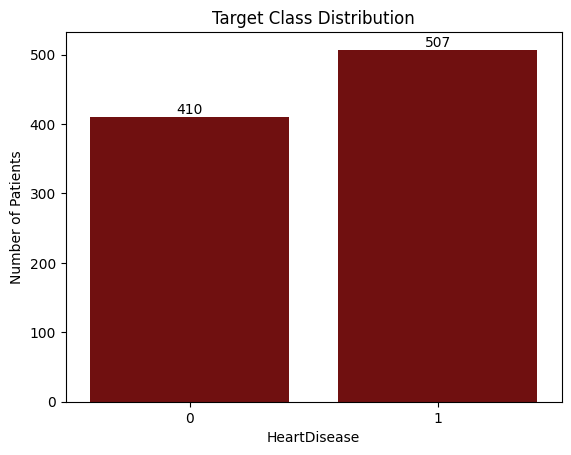

In [10]:
ax = sns.countplot(data = Heart_Disease, x = 'HeartDisease', color='maroon')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Target Class Distribution')
plt.xlabel('HeartDisease')
plt.ylabel('Number of Patients')
plt.show()

#Percentage of Target class

In [11]:
Heart_Disease['HeartDisease'].value_counts(normalize=True).mul(100).round(2)

,proportion
HeartDisease,
1,55.29
0,44.71


#**NUMERICAL DISTRIBUTIONS**

#Age Histogram

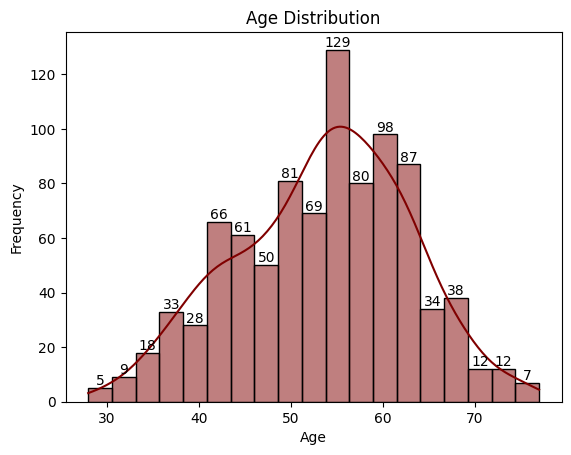

In [12]:
ax=sns.histplot(data=Heart_Disease, x='Age', kde=True, color='maroon')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

#Age Boxplot

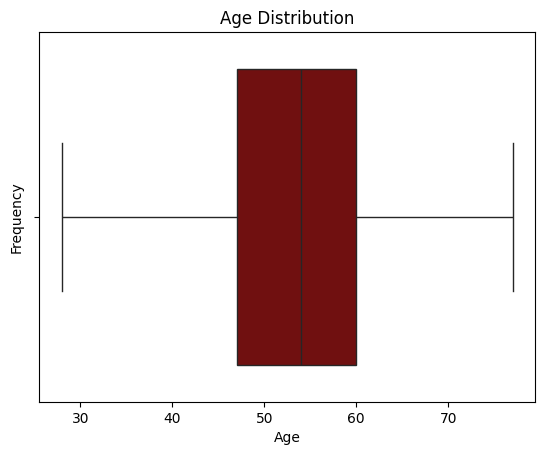

In [13]:
sns.boxplot(data=Heart_Disease, x='Age', color='maroon')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

#RestingBP Histogram

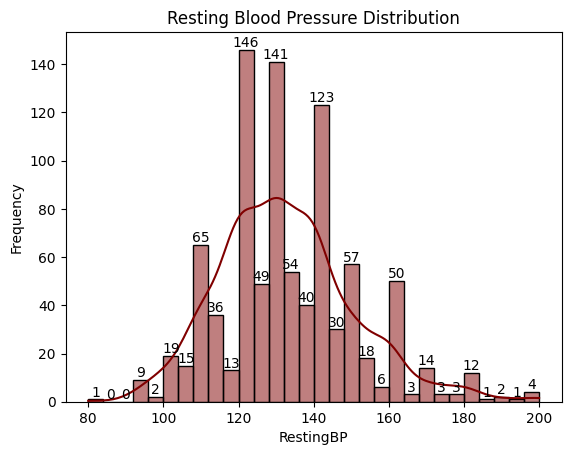

In [14]:
ax=sns.histplot(data=Heart_Disease, x='RestingBP', kde=True, color='maroon')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Resting Blood Pressure Distribution')
plt.xlabel('RestingBP')
plt.ylabel('Frequency')
plt.show()

#RestingBP Boxplot

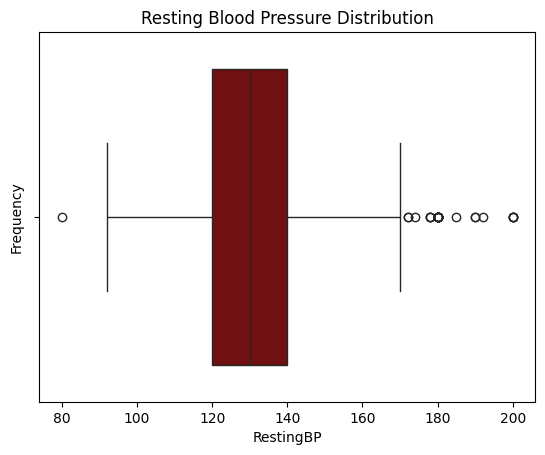

In [15]:
sns.boxplot(data=Heart_Disease, x='RestingBP', color='maroon')
plt.title('Resting Blood Pressure Distribution')
plt.xlabel('RestingBP')
plt.ylabel('Frequency')
plt.show()

#Cholesterol Histogram

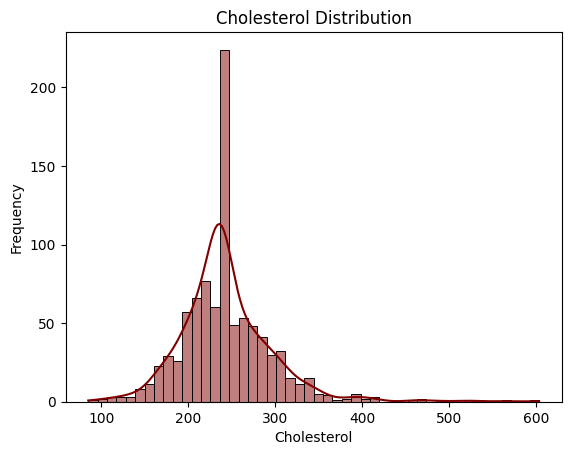

In [16]:
sns.histplot(data=Heart_Disease, x='Cholesterol', kde=True, color='maroon')
plt.title('Cholesterol Distribution')
plt.xlabel('Cholesterol')
plt.ylabel('Frequency')
plt.show()

#Cholesterol Boxplot

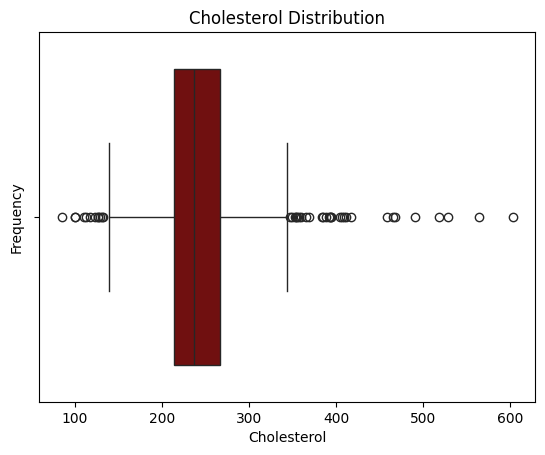

In [17]:
sns.boxplot(data=Heart_Disease, x='Cholesterol', color='maroon')
plt.title('Cholesterol Distribution')
plt.xlabel('Cholesterol')
plt.ylabel('Frequency')
plt.show()

#Maximum Heart Rate

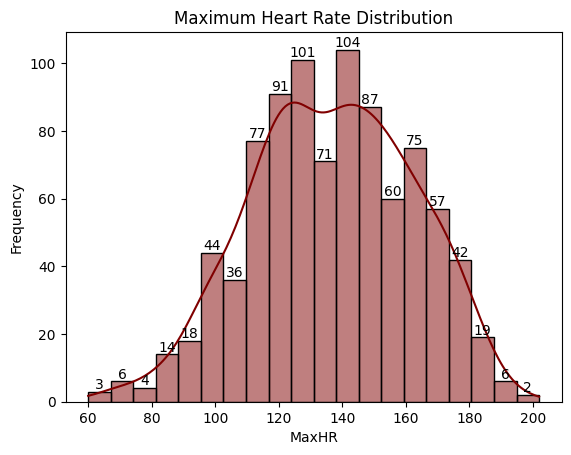

In [18]:
ax=sns.histplot(data=Heart_Disease, x='MaxHR', kde=True, color='maroon')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Maximum Heart Rate Distribution')
plt.xlabel('MaxHR')
plt.ylabel('Frequency')
plt.show()

#Maximum Heart Rate Boxplot

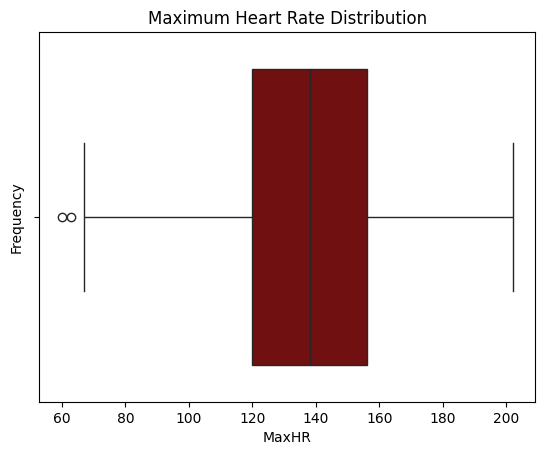

In [19]:
sns.boxplot(data=Heart_Disease, x='MaxHR', color='maroon')
plt.title('Maximum Heart Rate Distribution')
plt.xlabel('MaxHR')
plt.ylabel('Frequency')
plt.show()

#Oldpeak Histogram

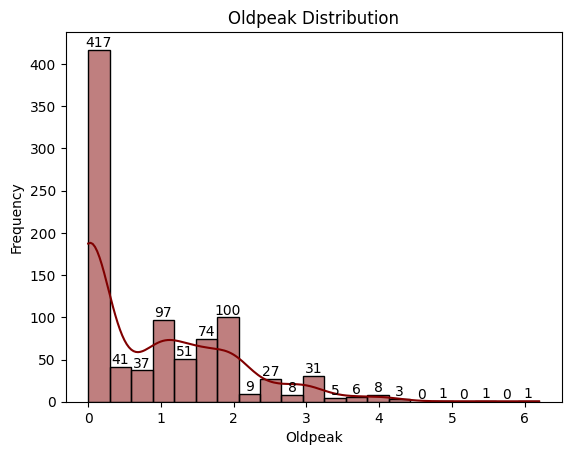

In [20]:
ax=sns.histplot(data=Heart_Disease, x='Oldpeak', kde=True, color='maroon')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Oldpeak Distribution')
plt.xlabel('Oldpeak')
plt.ylabel('Frequency')
plt.show()

#Oldpeak Boxplot

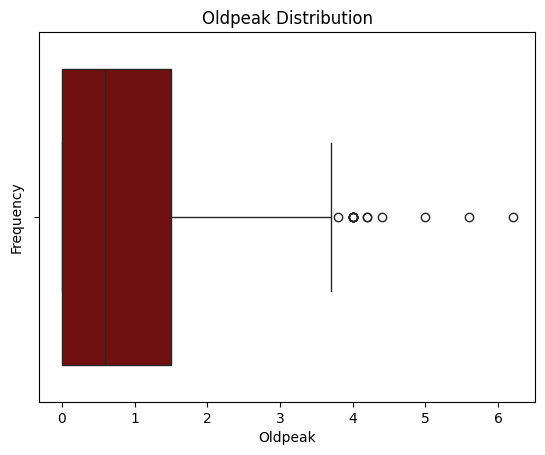

In [21]:
sns.boxplot(data=Heart_Disease, x='Oldpeak', color='maroon')
plt.title('Oldpeak Distribution')
plt.xlabel('Oldpeak')
plt.ylabel('Frequency')
plt.show()

#**CATEGORICAL DISTRIBUTIONS**

#Sex

/tmp/ipykernel_4111/687919491.py:1: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:maroon'` for the same effect.

  ax=sns.countplot(data=Heart_Disease, x='Sex', color='maroon', hue='HeartDisease')


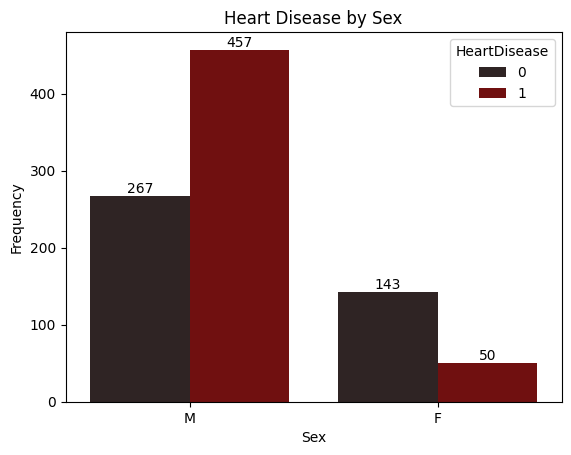

In [22]:
ax=sns.countplot(data=Heart_Disease, x='Sex', color='maroon', hue='HeartDisease')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Heart Disease by Sex')
plt.xlabel('Sex')
plt.ylabel('Frequency')
plt.show()

#Chest Pain Type

/tmp/ipykernel_4111/461016269.py:1: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:maroon'` for the same effect.

  ax=sns.countplot(data=Heart_Disease, x='ChestPainType', color='maroon', hue='HeartDisease')


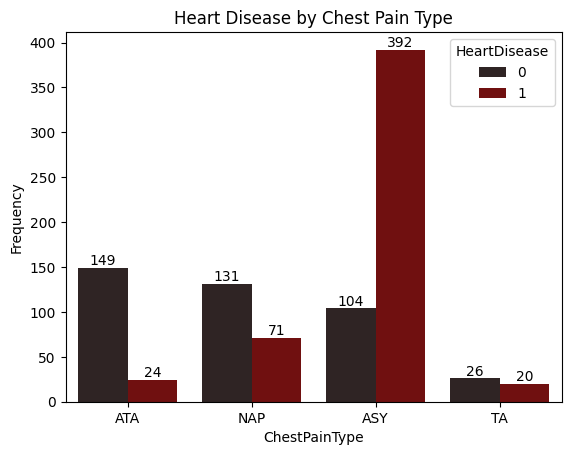

In [23]:
ax=sns.countplot(data=Heart_Disease, x='ChestPainType', color='maroon', hue='HeartDisease')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Heart Disease by Chest Pain Type')
plt.xlabel('ChestPainType')
plt.ylabel('Frequency')
plt.show()

#Resting ECG

/tmp/ipykernel_4111/1944291174.py:1: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:maroon'` for the same effect.

  ax=sns.countplot(data=Heart_Disease, x='RestingECG', color='maroon', hue='HeartDisease')


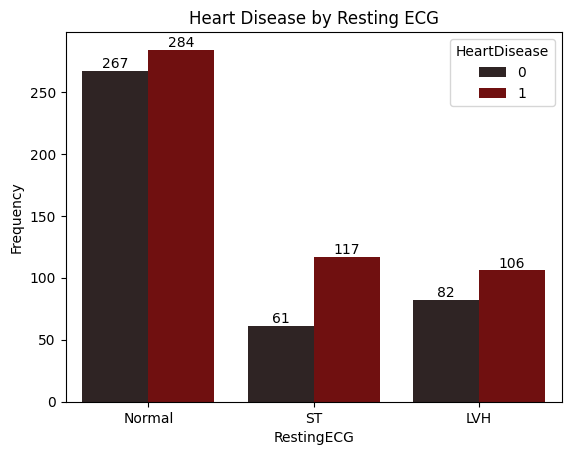

In [24]:
ax=sns.countplot(data=Heart_Disease, x='RestingECG', color='maroon', hue='HeartDisease')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Heart Disease by Resting ECG')
plt.xlabel('RestingECG')
plt.ylabel('Frequency')
plt.show()

#Exercise Angina

/tmp/ipykernel_4111/2196225991.py:1: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:maroon'` for the same effect.

  ax=sns.countplot(data=Heart_Disease, x='ExerciseAngina', color='maroon', hue='HeartDisease')


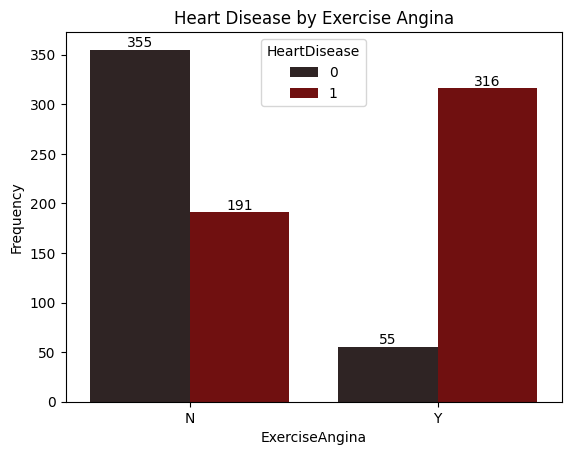

In [25]:
ax=sns.countplot(data=Heart_Disease, x='ExerciseAngina', color='maroon', hue='HeartDisease')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Heart Disease by Exercise Angina')
plt.xlabel('ExerciseAngina')
plt.ylabel('Frequency')
plt.show()

#ST Slope

/tmp/ipykernel_4111/3437287042.py:1: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:maroon'` for the same effect.

  ax=sns.countplot(data=Heart_Disease, x='ST_Slope', color='maroon', hue='HeartDisease')


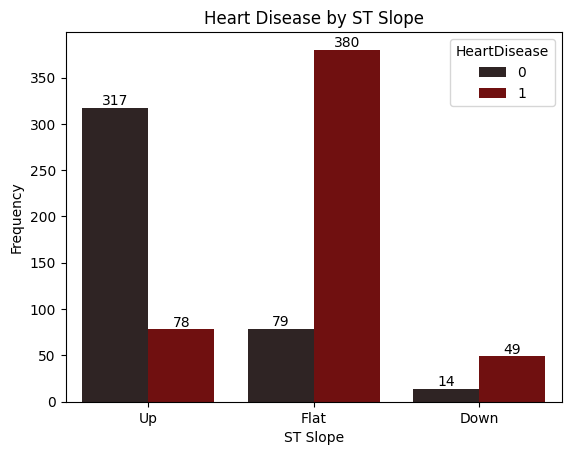

In [26]:
ax=sns.countplot(data=Heart_Disease, x='ST_Slope', color='maroon', hue='HeartDisease')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Heart Disease by ST Slope')
plt.xlabel('ST Slope')
plt.ylabel('Frequency')
plt.show()

#**NUMERICAL VS TARGET**

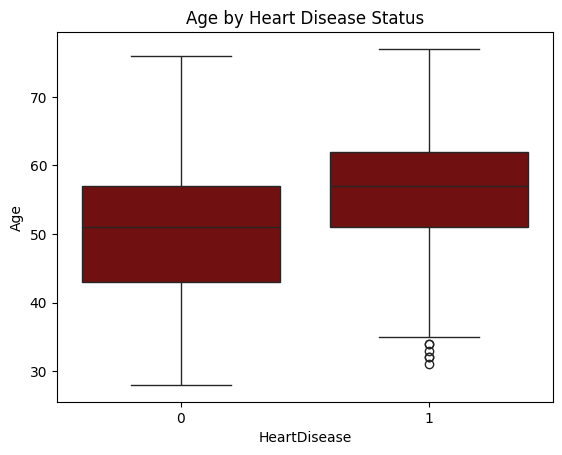

In [27]:
sns.boxplot(data=Heart_Disease, x='HeartDisease', y='Age', color='maroon')
plt.title('Age by Heart Disease Status')
plt.xlabel('HeartDisease')
plt.ylabel('Age')
plt.show()

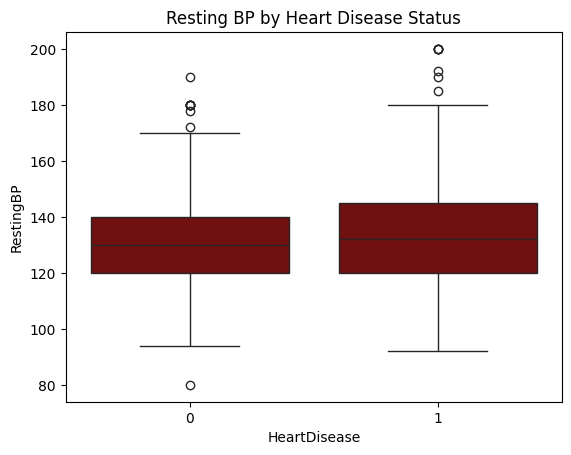

In [28]:
sns.boxplot(data=Heart_Disease, x='HeartDisease', y='RestingBP', color='maroon')
plt.title('Resting BP by Heart Disease Status')
plt.xlabel('HeartDisease')
plt.ylabel('RestingBP')
plt.show()

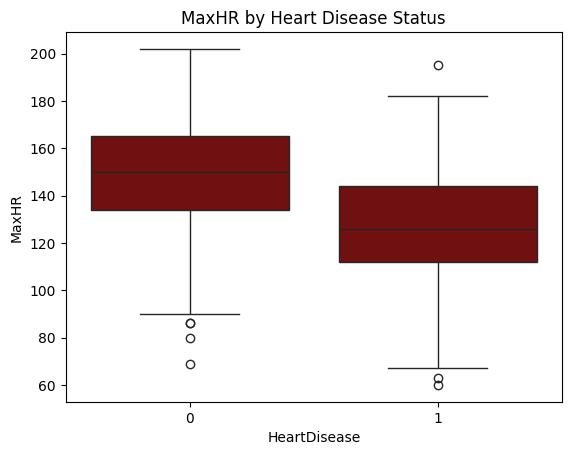

In [29]:
sns.boxplot(data=Heart_Disease, x='HeartDisease', y='MaxHR', color='maroon')
plt.title('MaxHR by Heart Disease Status')
plt.xlabel('HeartDisease')
plt.ylabel('MaxHR')
plt.show()

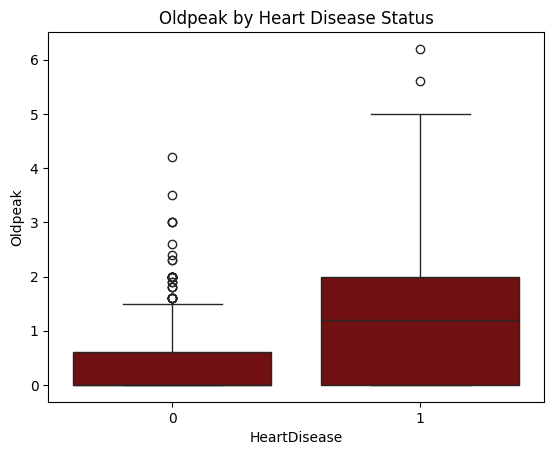

In [30]:
sns.boxplot(data=Heart_Disease, x='HeartDisease', y='Oldpeak', color='maroon')
plt.title('Oldpeak by Heart Disease Status')
plt.xlabel('HeartDisease')
plt.ylabel('Oldpeak')
plt.show()

#Correlation Heatmap

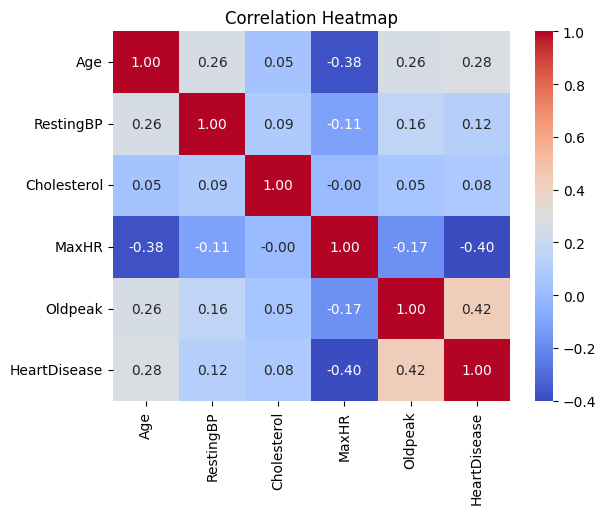

In [31]:
correlation = Heart_Disease[numerical_columns + ['HeartDisease']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

#Pairplot/Multivariate Analysis

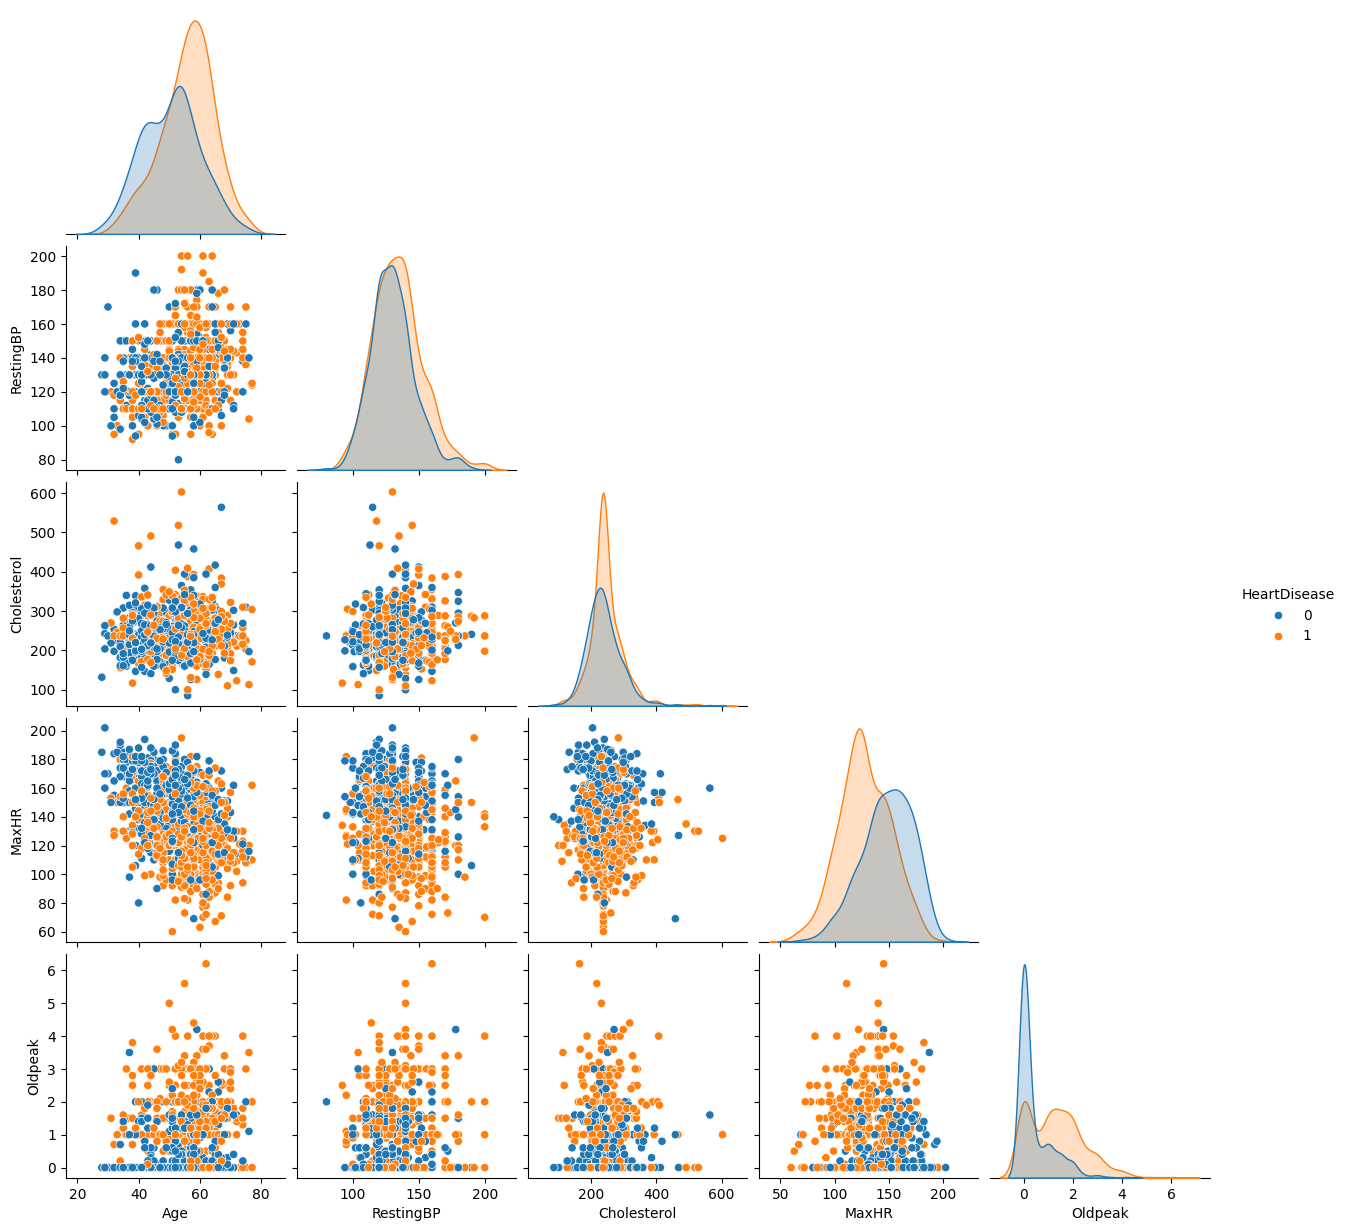

In [32]:
sns.pairplot(Heart_Disease[['Age','RestingBP','Cholesterol','MaxHR','Oldpeak','HeartDisease']], hue='HeartDisease', corner='True')
plt.show()

#Categorical Cross Tabulations

In [33]:
def categorical_target_analysis(data,column):
  table = pd.crosstab(data[column], data['HeartDisease'])
  percentage = pd.crosstab(data[column], data['HeartDisease'], normalize='index'). mul(100).round(2)
  return table, percentage

In [34]:
table, percentage = categorical_target_analysis(Heart_Disease, 'ChestPainType')
print('counts:')
display(table)
print('percentage:')
display(percentage)

counts:


HeartDisease,0,1
ChestPainType,,
ASY,104,392
ATA,149,24
NAP,131,71
TA,26,20


percentage:


HeartDisease,0,1
ChestPainType,,
ASY,20.97,79.03
ATA,86.13,13.87
NAP,64.85,35.15
TA,56.52,43.48


In [35]:
for col in categorical_columns:
  print('\n', '='*50)
  print(col)
  counts=pd.crosstab(Heart_Disease[col], Heart_Disease['HeartDisease'])
  percentage = pd.crosstab(Heart_Disease[col], Heart_Disease['HeartDisease'], normalize='index'). mul(100).round(2)
  display(counts)
  display(percentage)


Sex


HeartDisease,0,1
Sex,,
F,143,50
M,267,457


HeartDisease,0,1
Sex,,
F,74.09,25.91
M,36.88,63.12



ChestPainType


HeartDisease,0,1
ChestPainType,,
ASY,104,392
ATA,149,24
NAP,131,71
TA,26,20


...

HeartDisease,0,1
ST_Slope,,
Down,14,49
Flat,79,380
Up,317,78


HeartDisease,0,1
ST_Slope,,
Down,22.22,77.78
Flat,17.21,82.79
Up,80.25,19.75



FastingBS


HeartDisease,0,1
FastingBS,,
0,366,337
1,44,170


HeartDisease,0,1
FastingBS,,
0,52.06,47.94
1,20.56,79.44


#**STATISTICAL ANALYSIS**

#Pearson Correlation

In [36]:
r,p_value = pearsonr(Heart_Disease['Age'], Heart_Disease['Oldpeak'])
print('Pearson Correlation:', round(r,4))
print('P-value:', p_value)

Pearson Correlation: 0.2614
P-value: 8.648784665141955e-16


#Chi-Square Test

In [37]:
contingency_table = pd.crosstab(Heart_Disease['ChestPainType'], Heart_Disease['HeartDisease'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print('Chi-Square Statistic:', round(chi2,4))
print('Degrees of Freedom:',dof)
print('P-value:', p_value)

Chi-Square Statistic: 268.8963
Degrees of Freedom: 3
P-value: 5.348821918587953e-58


#Cramer's V

In [38]:
def cramers_v(table):
  chi2=chi2_contingency(table)[0]
  n=table.sum().sum()
  r,k=table.shape
  return np.sqrt((chi2/n)/(min(k-1,r-1)))
  print('Cramer\'s V:', round(cramers_v(contingency_table),4))

#Independent Samples T-Test

In [39]:
no_disease=Heart_Disease.loc[Heart_Disease['HeartDisease']==0, 'MaxHR']
disease=Heart_Disease.loc[Heart_Disease['HeartDisease']==1, 'MaxHR']
t_statistic, p_value = ttest_ind(no_disease, disease, equal_var=False)
print('T-Statistic:', round(t_statistic,4))
print('P-value:', round(p_value,4))
print('Mean MaxHR.No Disease:', round(no_disease.mean(),2))
print('Mean MaxHR.Disease:', round(disease.mean(),2))

T-Statistic: 13.2626
P-value: 0.0
Mean MaxHR.No Disease: 148.15
Mean MaxHR.Disease: 127.6


#One-Way ANOVA

In [40]:
groups = [group['Oldpeak'].values for name, group in Heart_Disease.groupby('ChestPainType')]
f_statistic, p_value = f_oneway(*groups)
print('F-statistic:', round(f_statistic,4))
print('P-value:', p_value)

F-statistic: 37.3484
P-value: 9.044370641358466e-23


#Statistical Results Summary Table

In [41]:
statistical_results = pd.DataFrame({'Test': ['Pearson Correlation', 'Chi-Square Test', 'Cramer\'s V', 'One-Way ANOVA'],
                                    'Statistic': [r,chi2,t_statistic,f_statistic],
                                    'Variables':['Age vs Oldpeak','ChestPainType vs HeartDisease','MaxHR vs HeartDisease','Oldpeak vs ChestPainType'],
                                    'P-value': [pearson_p if False else np.nan, np.nan, np.nan, np.nan]})
print(statistical_results)


                  Test   Statistic                      Variables  P-value
0  Pearson Correlation    0.261383                 Age vs Oldpeak      NaN
1      Chi-Square Test  268.896258  ChestPainType vs HeartDisease      NaN
2           Cramer's V   13.262607          MaxHR vs HeartDisease      NaN
3        One-Way ANOVA   37.348433       Oldpeak vs ChestPainType      NaN


#**FEATURE ENGINEERING**

#Age Group

In [42]:
Heart_Disease['AgeGroup'] = pd.cut(Heart_Disease['Age'], bins=[0, 39, 49, 59, 69, 100], labels=['Young', 'Middle-Age', '50s', '60s','70plus'])


#Blood Pressure Category

In [43]:
def blood_pressure_category(bp):
    if bp < 120:
        return 'Normal'
    elif bp < 130:
        return 'Elevated'
    elif bp < 140:
         return 'High Stage 1'
    else:
        return 'High Stage 2'
    Heart_Disease['BP_Category']=Heart_Disease['RestingBP'].apply(bp_category)

#Cholesterol Risk Level

In [44]:
def cholesterol_risk_level(cholesterol):
    if cholesterol < 200:
        return 'Normal'
    elif cholesterol < 240:
        return 'Elevated'
    else:
        return 'High'
    Heart_Disease['Cholesterol_Risk_Level']=Heart_Disease['Cholesterol'].apply(cholesterol_risk_level)

#Maximum HR Category

In [45]:
Heart_Disease['MaxHR_Category'] = pd.cut(Heart_Disease['MaxHR'], bins=[0, 100, 130, 160, 220], labels = ['low', 'normal', 'high', 'very high'])


#Exercise Stress Indicator

In [46]:
Heart_Disease['Exercise_Stress']=((Heart_Disease['ExerciseAngina']=='Y')|(Heart_Disease['Oldpeak']>1)).astype(int)

#**FEATURE SELECTION**

#Numerical Correlation with Target

In [47]:
numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
correlation_with_target = Heart_Disease[numeric_features + ['HeartDisease']].corr()['HeartDisease'].sort_values(key = abs, ascending=False)
print(correlation_with_target)

HeartDisease    1.000000
Oldpeak         0.420164
MaxHR          -0.401410
Age             0.282012
RestingBP       0.117990
Cholesterol     0.076262
Name: HeartDisease, dtype: float64


#Correlation between Predictors

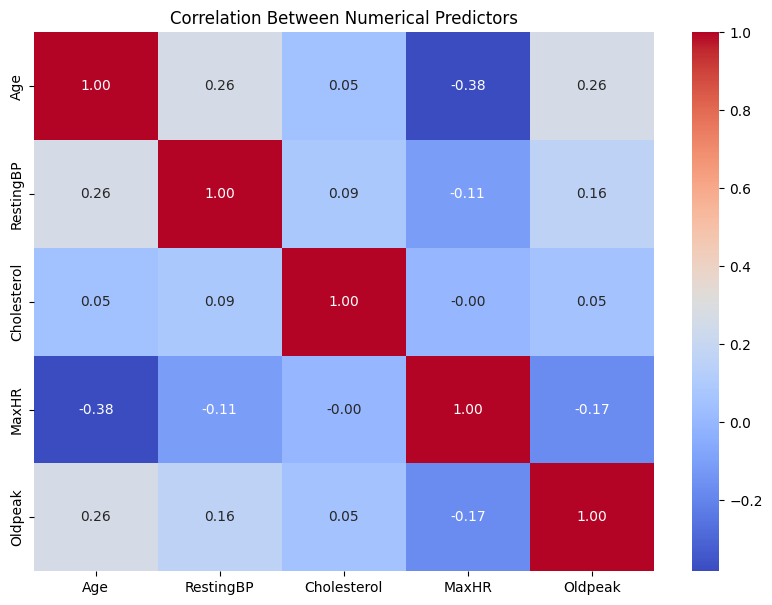

In [48]:
predictor_correlation = Heart_Disease[numeric_features].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(predictor_correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Numerical Predictors')
plt.show()


#Categorical Feature Association

In [49]:
categorical_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
categorical_results = []
for col in categorical_features:
    table = pd.crosstab(Heart_Disease[col], Heart_Disease['HeartDisease'])
    chi2, p, dof, expected = chi2_contingency(table)
    categorical_results.append({'Feature': col, 'Chi2': chi2, 'P-value': p, 'Cramers_V': cramers_v(table)})
categorical_results = pd.DataFrame(categorical_results).sort_values(by='P-value')
print(categorical_results)

          Feature        Chi2       P-value  Cramers_V
4        ST_Slope  355.155699  7.566933e-78   0.622336
1   ChestPainType  268.896258  5.348822e-58   0.541512
3  ExerciseAngina  223.107207  1.899519e-50   0.493256
0             Sex   83.871151  5.280956e-20   0.302428
2      RestingECG   11.069537  3.947123e-03   0.109870


#Numerical Feature Statistical Association

In [50]:
numeric_results = []
for col in numeric_features:
    r,p = stats.pointbiserialr(Heart_Disease[col], Heart_Disease['HeartDisease'])
    numeric_results.append({'Feature': col, 'Correlation': r, 'P-value': p})
numeric_results = pd.DataFrame(numeric_results).sort_values(by='P-value')
print(numeric_results)

       Feature  Correlation       P-value
4      Oldpeak     0.420164  1.593668e-40
3        MaxHR    -0.401410  8.044073e-37
0          Age     0.282012  3.160837e-18
1    RestingBP     0.117990  3.427866e-04
2  Cholesterol     0.076262  2.091190e-02


#Mutual Information

In [51]:
mi_data = Heart_Disease.dropna().copy()
X = mi_data.drop(columns=['HeartDisease'])
y = mi_data['HeartDisease']
X_encoded = pd.get_dummies(X, drop_first=True)
mi_scores = mutual_info_classif(X_encoded, y, random_state=42)
mi_scores = pd.DataFrame({'Feature': X_encoded.columns, 'Mutual Information': mi_scores}).sort_values(by='Mutual Information', ascending=False)
print(mi_scores)


                     Feature  Mutual Information
15               ST_Slope_Up            0.192931
14             ST_Slope_Flat            0.147098
6            Exercise_Stress            0.144110
13          ExerciseAngina_Y            0.137667
4                      MaxHR            0.094543
5                    Oldpeak            0.094372
2                Cholesterol            0.072607
8          ChestPainType_ATA            0.067274
7                      Sex_M            0.060921
3                  FastingBS            0.053206
20     MaxHR_Category_normal            0.048804
0                        Age            0.043752
22  MaxHR_Category_very high            0.039997
18              AgeGroup_60s            0.035428
12             RestingECG_ST            0.007952
21       MaxHR_Category_high            0.005551
16       AgeGroup_Middle-Age            0.002165
9          ChestPainType_NAP            0.000041
1                  RestingBP            0.000000
11         RestingEC

#**PREPARING MACHINE LEARNING DATASET**

#Drop Target and Separate X/y

In [52]:
X = Heart_Disease.drop(columns=['HeartDisease'])
y = Heart_Disease['HeartDisease']


#One Hot Encoding

In [53]:
X_encoded = pd.get_dummies(X, drop_first=True)
print(X_encoded.head())

   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  Exercise_Stress  \
0   40        140          289          0    172      0.0                0   
1   49        160          180          0    156      1.0                0   
2   37        130          283          0     98      0.0                0   
3   48        138          214          0    108      1.5                1   
4   54        150          195          0    122      0.0                0   

   Sex_M  ChestPainType_ATA  ChestPainType_NAP  ...  ExerciseAngina_Y  \
0   True               True              False  ...             False   
1  False              False               True  ...             False   
2   True               True              False  ...             False   
3  False              False              False  ...              True   
4   True              False               True  ...             False   

   ST_Slope_Flat  ST_Slope_Up  AgeGroup_Middle-Age  AgeGroup_50s  \
0          False        

#Checking Dimensions

In [54]:
print('Original Features:', X.shape[1])
print('Encoded Features:', X_encoded.shape[1])

Original Features: 14
Encoded Features: 23


#Feature Scaling

In [55]:
scaler = StandardScaler()
scale_columns = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
X_encoded[scale_columns] = scaler.fit_transform(X_encoded[scale_columns])
print(X_encoded.head())

        Age  RestingBP  Cholesterol  FastingBS     MaxHR   Oldpeak  \
0 -1.432206   0.414627     0.857447          0  1.383339 -0.861942   
1 -0.478057   1.526360    -1.183717          0  0.754736  0.095076   
2 -1.750256  -0.141240     0.745089          0 -1.523953 -0.861942   
3 -0.584074   0.303453    -0.547024          0 -1.131075  0.573584   
4  0.052026   0.970493    -0.902823          0 -0.581047 -0.861942   

   Exercise_Stress  Sex_M  ChestPainType_ATA  ChestPainType_NAP  ...  \
0                0   True               True              False  ...   
1                0  False              False               True  ...   
2                0   True               True              False  ...   
3                1  False              False              False  ...   
4                0   True              False               True  ...   

   ExerciseAngina_Y  ST_Slope_Flat  ST_Slope_Up  AgeGroup_Middle-Age  \
0             False          False         True                 True   
1 

#Final Machine Learning Dataset

In [56]:
ml_dataset= X_encoded.copy()
ml_dataset['HeartDisease']= y
print('Final dataset shape:',ml_dataset.shape)
print(ml_dataset.head())

Final dataset shape: (917, 24)
        Age  RestingBP  Cholesterol  FastingBS     MaxHR   Oldpeak  \
0 -1.432206   0.414627     0.857447          0  1.383339 -0.861942   
1 -0.478057   1.526360    -1.183717          0  0.754736  0.095076   
2 -1.750256  -0.141240     0.745089          0 -1.523953 -0.861942   
3 -0.584074   0.303453    -0.547024          0 -1.131075  0.573584   
4  0.052026   0.970493    -0.902823          0 -0.581047 -0.861942   

   Exercise_Stress  Sex_M  ChestPainType_ATA  ChestPainType_NAP  ...  \
0                0   True               True              False  ...   
1                0  False              False               True  ...   
2                0   True               True              False  ...   
3                1  False              False              False  ...   
4                0   True              False               True  ...   

   ST_Slope_Flat  ST_Slope_Up  AgeGroup_Middle-Age  AgeGroup_50s  \
0          False         True                 T

#Save Dataset

In [57]:
ml_dataset.to_csv('heart_ disease_ ml_ready.csv', index=False)
print('Machine Learning dataset downloaded')

Machine Learning dataset downloaded
